In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from torch_geometric.datasets import Planetoid

c:\Users\anand\Desktop\Research Topic Classification GNN Project\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Load CORA Dataset

In [2]:
dataset = Planetoid(root="data/Planetoid", name="Cora")

Processing...
Done!


In [13]:
data = dataset[0]

print(f"Number of nodes(Research Papers): {data.num_nodes}")
print(f"Number of edges(Citations): {data.num_edges}")
print(f"Number of features per paper: {data.num_features}")
print(f"Labels per paper: {dataset.num_classes}")


print(f"Training papers: {data.train_mask.sum()}")
print(f"Validation papers: {data.val_mask.sum()}")
print(f"Testing papers: {data.test_mask.sum()}")

Number of nodes(Research Papers): 2708
Number of edges(Citations): 10556
Number of features per paper: 1433
Labels per paper: 7
Training papers: 140
Validation papers: 500
Testing papers: 1000


<Axes: xlabel='None', ylabel='count'>

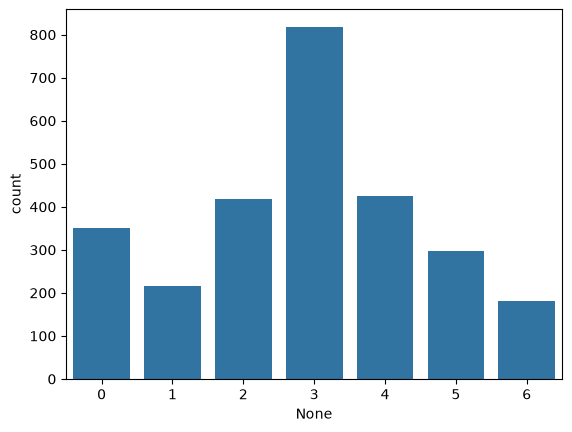

In [19]:
topic_counts = pd.Series(data.y.numpy()).value_counts().sort_index()

indexes = topic_counts.index

sns.barplot(x=indexes, y=topic_counts)

In [20]:
X_binary = data.x.numpy()
y = data.y.numpy()

In [22]:
from sklearn.feature_extraction.text import TfidfTransformer

tfidf = TfidfTransformer()
X_tfidf = tfidf.fit_transform(X_binary).toarray()
X_baseline = X_tfidf

train_idx = data.train_mask.numpy()
val_idx = data.val_mask.numpy()
test_idx = data.test_mask.numpy()


X_train, y_train = X_baseline[train_idx], y[train_idx]
X_test, y_test = X_baseline[test_idx], y[test_idx]

In [24]:
from sklearn.ensemble import RandomForestClassifier

random_forest = RandomForestClassifier(n_estimators=100, max_features="sqrt", class_weight="balanced", random_state=42, n_jobs=-1)
random_forest.fit(X_train, y_train)
random_forest_pred = random_forest.predict(X_test)

In [32]:
# Evaluation
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix

rf_accuracy = accuracy_score(y_test, random_forest_pred)*100
rf_f1 = f1_score(y_test, random_forest_pred, average="macro")*100

print(f"Random Forest Accuracy Score: {rf_accuracy:.4f}")
print(f"Random Forest F1 Score: {rf_f1:.4f}")

Random Forest Accuracy Score: 58.1000
Random Forest F1 Score: 56.9807


<Axes: >

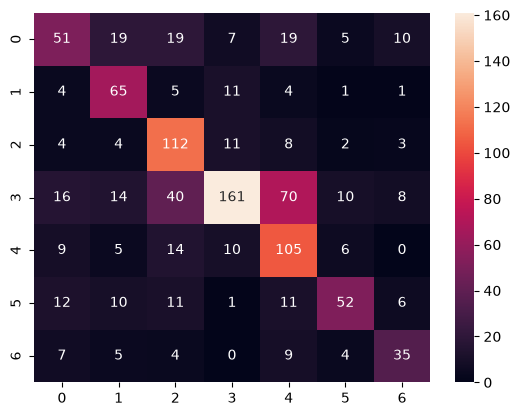

In [33]:
sns.heatmap(confusion_matrix(y_test, random_forest_pred), annot=True, fmt="d")